# PART 1) BASIC PRE-PROCESSING

In [ ]:
import nibabel as nib
import os
import matplotlib.pyplot as plt
import numpy as np

from utils.display import load_and_display, display_single_slice, compare_methods
from utils.segment import *

from config import *


In [3]:
t1_img, t1_hdr, t1_data, t1_dim          = load_and_display(T1_PATH, "T1-WEIGHTED", print_info=False)
mask, mask_hdr, mask_data, mask_dims     = load_and_display(MASK_PATH, 'MASK', print_info=False)
fmri_img, fmri_hdr, fmri_data, fmri_dims = load_and_display(FMRI_PATH, "FMRI", print_info=False)

### Tissue Segmentation
In the following cells I'm going to perform tissue segmentation using these methods:
- K-means clustering
- Multi-thresh Otsu algorithm
- Adaptive thresholding
- Simple threshold

In [4]:
bool_mask = mask_data.astype(bool)

t1_brain_1d = t1_data[bool_mask]              # we get a column vector of the brain voxels, which is what we want to segment
t1_brain_2d = np.where(bool_mask, t1_data, 0) # to keep the same dimensions as the original image, we set the background to 0

kmean_segmented = kmean_segmentation(t1_data, t1_brain_1d, bool_mask, 3)

otsu_threshold = otsu_segmentation(t1_brain_1d)
regions = np.digitize(t1_brain_1d, bins=otsu_threshold)
otsu_segmented = np.zeros_like(t1_data)
otsu_segmented[bool_mask] = regions

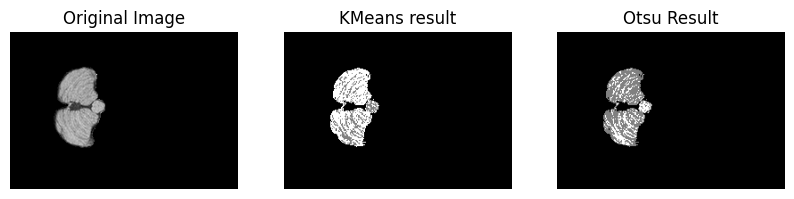

In [5]:
# Call of function to compare the two methods implemented 

compare_methods(t1_brain_2d, kmean_segmented, otsu_segmented, slice_idx=101)

## Low pass filtering in the frequency domain on a single axial slice and edge detection

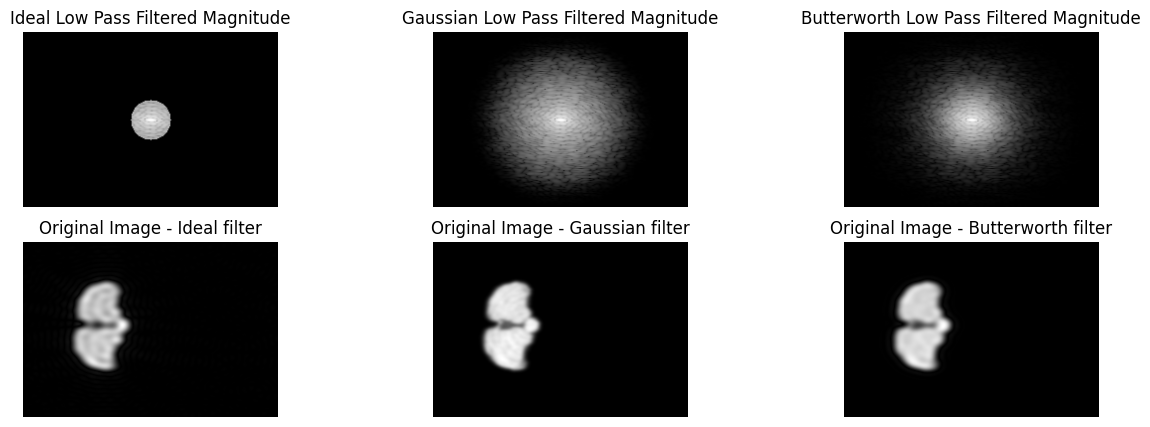

In [6]:
# 1) trasformare con 2d dft l'immagine di uno slice selezionato
# 2) visualizzare l'immagine in frequenza
# 3) andrà fatto un centering delle frequenze
# 4) implementare filtri passa basso: butter worth, gaussian, scalino usando praticamente delle maschere create con soglie di distanza dal centro
# 5) edge detection: convoluzione con filtri derivata prima, derivata seconda, LoG, DoG... e alla fine metodo più forte = Canny magari con trasformata Hough

from utils.statistics import _get_slice
from utils.filtering import low_pass_filter

slice_prova, _ = _get_slice(t1_brain_2d, slice_idx=101)
low_pass_filter(slice_prova, threshold=20)

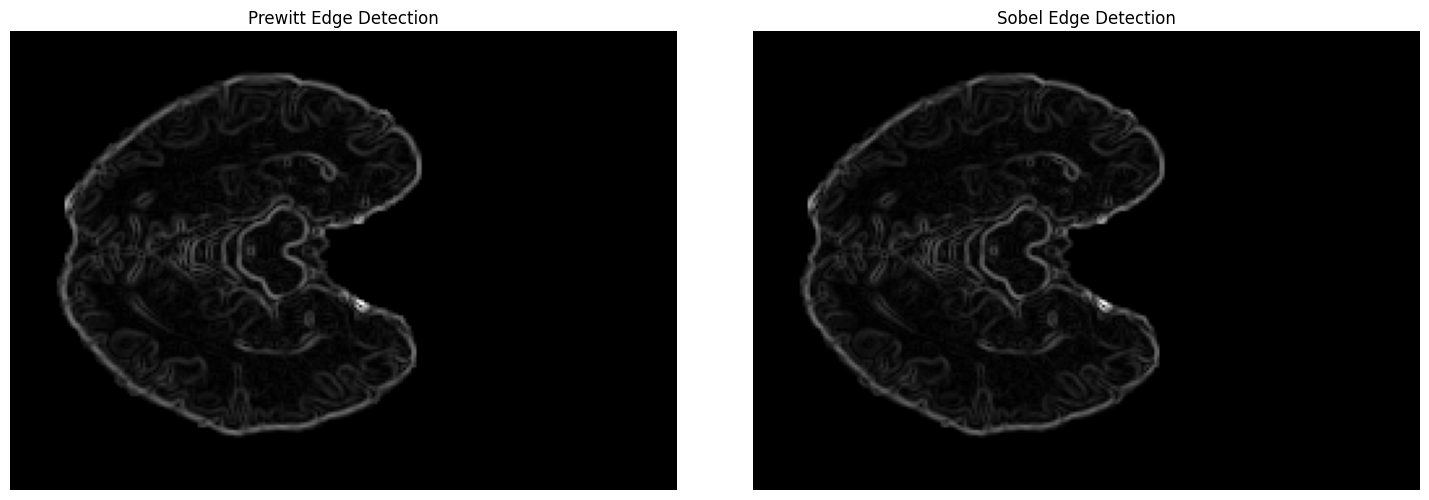

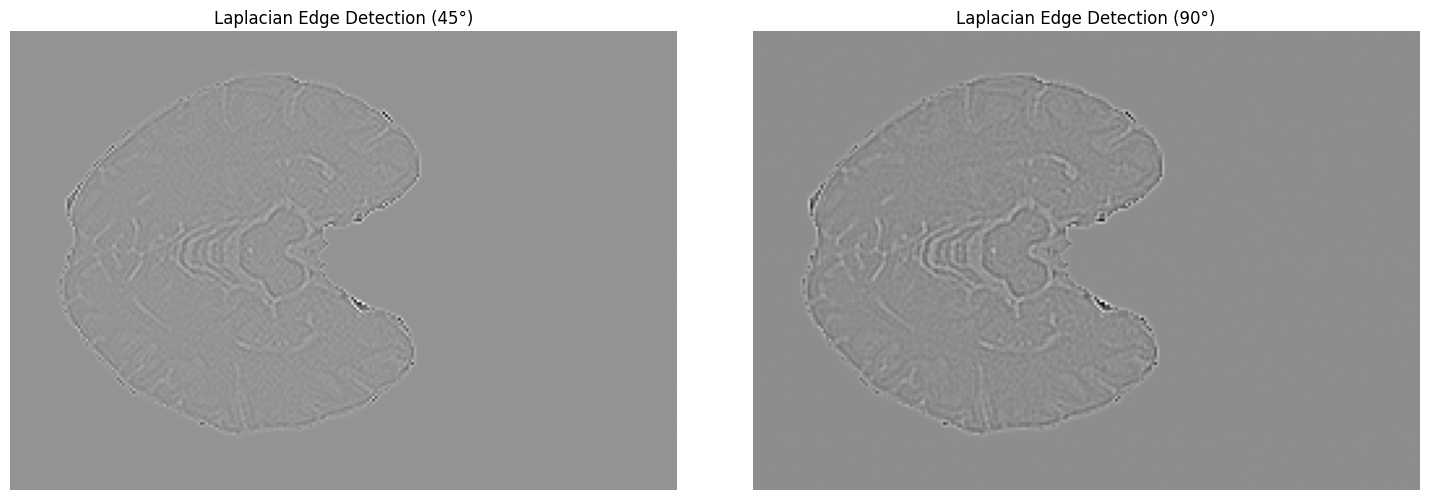

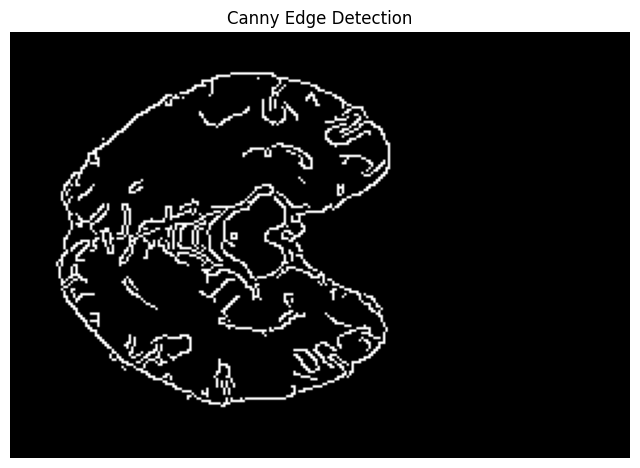

In [7]:
from utils.filtering import first_derivative_edge_detection, second_derivative_edge_detection, canny_edge_detection
slice_prova, _ = _get_slice(t1_brain_2d, slice_idx=150)
first_derivative_edge_detection(slice_prova)
second_derivative_edge_detection(slice_prova)
canny_edge_detection(slice_prova)


## On fmri4d data apply gaussian smoothing on all the volumes to obtain fmri4d_smoothed

For this part I'm asked to perform gaussian smoothing not on 2d images but on 3d structures, so I cannot use cv.GaussianBlur that performs a blurring on 2D images --> looking on internet I see that scipy.ndimage.gaussian_filter performs a smoothing on n-dim images

In [8]:
from utils.filtering import fmri_volumes_smoothing

fmri_smoothed = fmri_volumes_smoothing(fmri_data)